# Binary latent fork generator sanity checks

This notebook checks the simplified binary latent fork generator before training any models.

Expected behaviour:

- context is entirely pre-fork;
- the two regimes are exactly identical before the fork;
- one global latent branch variable `z ∈ {-1,+1}` is sampled per task;
- post-fork futures split into upper/lower branches;
- dense orange curves are exact realised latent functions sampled jointly with the plotted task inputs.


In [2]:
%matplotlib inline

from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import torch
from hydra.utils import instantiate
from omegaconf import OmegaConf

REPO_ROOT = Path("/scratch2/ij292/tnp-crps").resolve()
EXPERIMENTS_DIR = REPO_ROOT / "experiments"
EXTERNAL_TNP_DIR = REPO_ROOT / "external" / "tnp"

# Make notebook imports match the terminal environment.
for path in [str(EXTERNAL_TNP_DIR), str(EXPERIMENTS_DIR), str(REPO_ROOT)]:
    if path not in sys.path:
        sys.path.insert(0, path)

# Optional but useful: make relative paths behave as if launched from repo root.
os.chdir(REPO_ROOT)

from evaluate_synthetic_1d import load_merged_config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("repo:", REPO_ROOT)
print("external tnp:", EXTERNAL_TNP_DIR)

device: cuda
repo: /scratch2/ij292/tnp-crps
external tnp: /scratch2/ij292/tnp-crps/external/tnp


In [3]:
cfg_path = REPO_ROOT / 'experiments/configs/generators/binary_latent_fork_1d.yml'

cfg = load_merged_config(
    config_paths=[str(cfg_path)],
    overrides=[],
)
OmegaConf.set_struct(cfg, False)

# Deterministic notebook samples.
cfg.generators.test.deterministic = True
cfg.generators.test.deterministic_seed = 1
cfg.generators.test.batch_size = 16
cfg.generators.test.return_gt_pred = True

gen = instantiate(cfg.generators.test)
loader = torch.utils.data.DataLoader(gen, batch_size=None, num_workers=0)
batch = next(iter(loader))

print('xc', batch.xc.shape)
print('yc', batch.yc.shape)
print('xt', batch.xt.shape)
print('yt', batch.yt.shape)
print('gt_pred', type(batch.gt_pred).__name__)
print('fork_locations[:5]', batch.gt_pred.fork_locations[:5])
print('sampled_regimes[:5]', batch.gt_pred.sampled_regimes[:5])
print('regime_z[:5]', batch.gt_pred.regime_z[:5])
print('regime_names[:5]', [batch.gt_pred.regime_name(int(r)) for r in batch.gt_pred.sampled_regimes[:5]])


Seed set to 1


xc torch.Size([16, 28, 1])
yc torch.Size([16, 28, 1])
xt torch.Size([16, 128, 1])
yt torch.Size([16, 128, 1])
gt_pred BinaryLatentForkGroundTruthPredictor
fork_locations[:5] tensor([0., 0., 0., 0., 0.])
sampled_regimes[:5] tensor([1, 0, 0, 1, 1])
regime_z[:5] tensor([ 1, -1, -1,  1,  1])
regime_names[:5] ['upper', 'lower', 'lower', 'upper', 'upper']


## Gate sanity check

The gate should be exactly zero before `x0`, smooth in `[x0, x0 + transition_width]`, and exactly one after the transition.


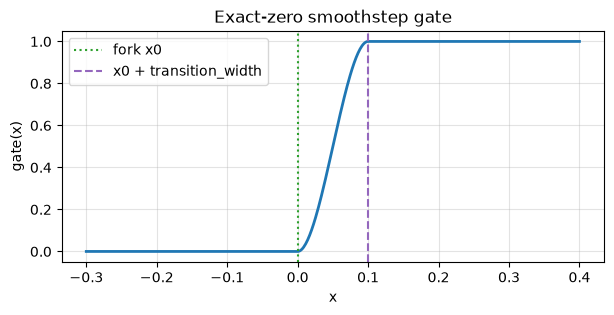

max gate for x <= 0: 0.0
min gate for x >= transition width: 1.0


In [4]:
gt = batch.gt_pred

x_gate = torch.linspace(-0.3, 0.4, 500)[None, :, None]
fork = torch.tensor([0.0])
gate = gt.gate(x_gate, fork)[0, :, 0]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x_gate[0, :, 0], gate, linewidth=2)
ax.axvline(0.0, color='tab:green', linestyle=':', label='fork x0')
ax.axvline(gt.transition_width, color='tab:purple', linestyle='--', label='x0 + transition_width')
ax.set_title('Exact-zero smoothstep gate')
ax.set_xlabel('x')
ax.set_ylabel('gate(x)')
ax.grid(True, alpha=0.35)
ax.legend()
plt.show()

print('max gate for x <= 0:', float(gate[x_gate[0, :, 0] <= 0].max()))
print('min gate for x >= transition width:', float(gate[x_gate[0, :, 0] >= gt.transition_width].min()))


## Function sanity plots

Each panel resamples the task inputs and dense plotting grid jointly, so the orange dense curve is the exact realised latent function for the displayed context/target observations.


In [5]:
def plot_generator_task(task_idx: int, ax=None, seed: int = 0, show_oracle_posterior: bool = True):
    torch.manual_seed(seed + task_idx)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 3))

    gt = batch.gt_pred
    nc = batch.xc.shape[1]

    # Original task input locations: context first, target second.
    x_task = torch.cat(
        [batch.xc[task_idx:task_idx + 1], batch.xt[task_idx:task_idx + 1]],
        dim=1,
    ).to(device)

    x_dense = torch.linspace(-4.0, 4.0, 512, device=device)[None, :, None]
    regime = gt.sampled_regimes[task_idx:task_idx + 1]

    y_task, f_dense = gt.sample_joint_observations_and_latent_function(
        x_observed=x_task,
        x_plot=x_dense,
        regimes=regime,
        store=False,
    )

    xc = x_task[:, :nc, :]
    yc = y_task[:, :nc, :]
    xt = x_task[:, nc:, :]
    yt = y_task[:, nc:, :]

    xd = x_dense[0, :, 0].detach().cpu()

    ax.plot(
        xd,
        f_dense[0, :, 0].detach().cpu(),
        color='tab:orange',
        linewidth=2.0,
        label='realised latent function',
    )

    if show_oracle_posterior:
        with torch.no_grad():
            mean, std, _ = gt(xc=xc, yc=yc, xt=x_dense)

        mean = mean[0].detach().cpu()
        std = std[0].detach().cpu()

        ax.plot(
            xd,
            mean,
            linestyle='--',
            color='tab:purple',
            linewidth=1.8,
            label='oracle posterior mean',
        )
        ax.fill_between(
            xd,
            mean - 2.0 * std,
            mean + 2.0 * std,
            color='tab:purple',
            alpha=0.12,
            label='oracle ±2 std',
        )

    ax.scatter(
        xc[0, :, 0].detach().cpu(),
        yc[0, :, 0].detach().cpu(),
        color='black',
        s=26,
        label='context',
        zorder=5,
    )
    ax.scatter(
        xt[0, :, 0].detach().cpu(),
        yt[0, :, 0].detach().cpu(),
        color='tab:red',
        s=10,
        alpha=0.35,
        label='targets',
        zorder=4,
    )

    fork_x0 = float(gt.fork_locations[task_idx])
    regime_id = int(regime.item())
    regime_name = gt.regime_name(regime_id)
    z = gt.regime_z_from_id(regime_id)

    ax.axvline(fork_x0, color='tab:green', linestyle=':', linewidth=2.0, label='fork')
    ax.axvspan(-4.0, -0.25, color='0.95', zorder=-10, label='context range')
    ax.axvspan(0.0, gt.transition_width, color='tab:green', alpha=0.08, zorder=-9, label='transition')

    ax.set_xlim(-4.0, 4.0)
    ax.grid(True, alpha=0.35)
    ax.set_title(
        f'task={task_idx} | regime={regime_name} (z={z:+d}) | '
        f'fork x0={fork_x0:.2f} | delta={gt.delta:.1f} | base_scale={gt.base_scale:.1f}'
    )
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    return ax


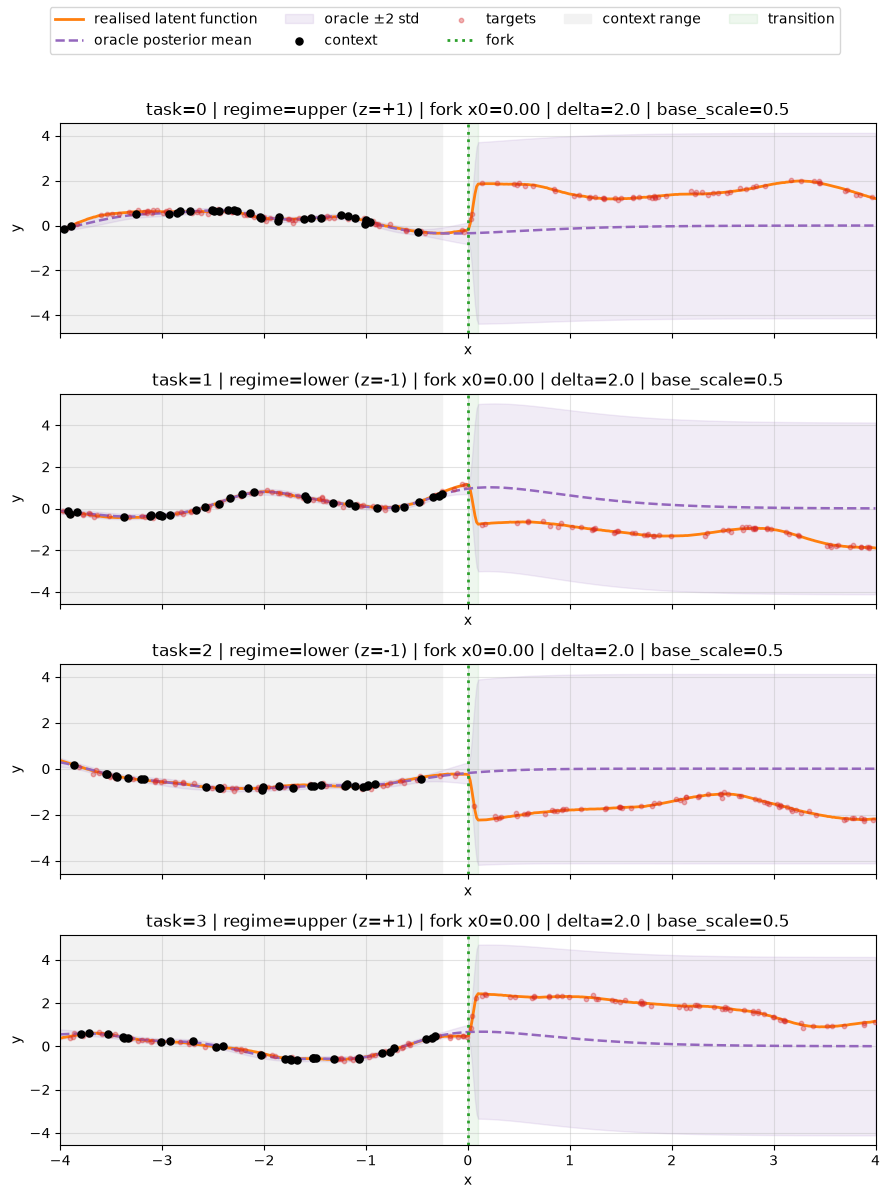

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(9, 12), sharex=True)

for task_idx, ax in enumerate(axes):
    plot_generator_task(task_idx, ax=ax, seed=123, show_oracle_posterior=True)

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=5)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()


## Oracle histogram sanity check

With pre-fork context, the oracle predictive should be unimodal before the fork and bimodal after the fork.

Probe locations:

- `x=-0.5`: pre-fork, unimodal;
- `x=0.05`: transition, partially separated;
- `x=0.25`: post-transition, strongly bimodal;
- `x=1.0`: far post-fork, clearly separated.


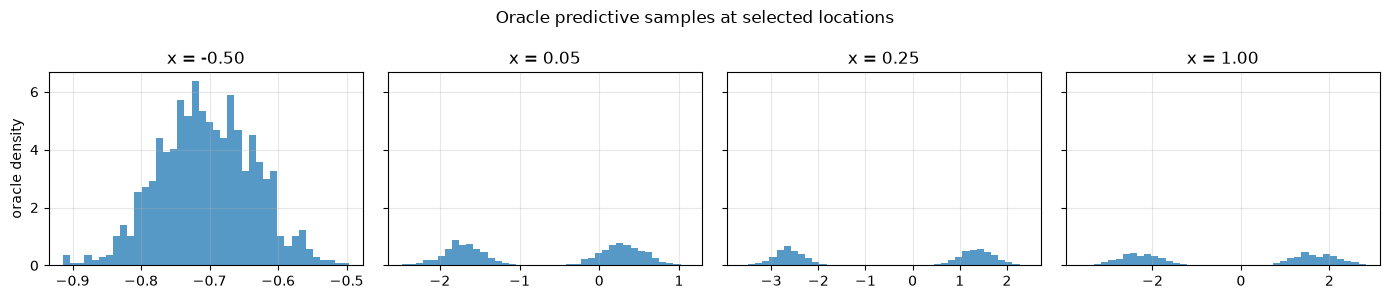

In [7]:
task_idx = 0
probe_x = torch.tensor([-0.5, 0.05, 0.25, 1.0], device=device)[None, :, None]

with torch.no_grad():
    oracle_samples = gt.predictive_samples(
        xc=batch.xc[task_idx:task_idx + 1].to(device),
        yc=batch.yc[task_idx:task_idx + 1].to(device),
        xt=probe_x,
        num_samples=1024,
    )[:, 0, :, 0].detach().cpu()

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)

for j, ax in enumerate(axes):
    ax.hist(oracle_samples[:, j].numpy(), bins=40, density=True, alpha=0.75)
    ax.set_title(f'x = {float(probe_x[0, j, 0]):.2f}')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('oracle density')
fig.suptitle('Oracle predictive samples at selected locations')
fig.tight_layout()
plt.show()


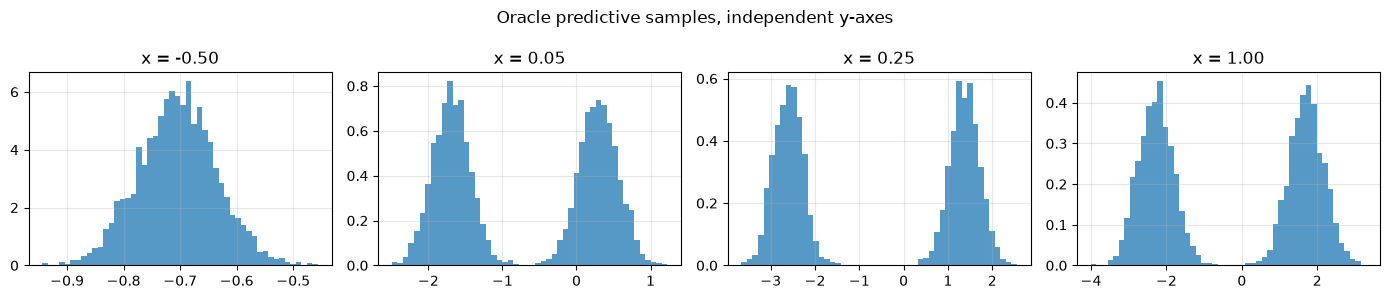

In [9]:
task_idx = 0
probe_x = torch.tensor([-0.5, 0.05, 0.25, 1.0], device=device)[None, :, None]

with torch.no_grad():
    oracle_samples = gt.predictive_samples(
        xc=batch.xc[task_idx:task_idx + 1].to(device),
        yc=batch.yc[task_idx:task_idx + 1].to(device),
        xt=probe_x,
        num_samples=4096,
    )[:, 0, :, 0].detach().cpu()

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=False)

for j, ax in enumerate(axes):
    vals = oracle_samples[:, j].numpy()
    ax.hist(vals, bins=50, density=True, alpha=0.75)
    ax.set_title(f"x = {float(probe_x[0, j, 0]):.2f}")
    ax.grid(True, alpha=0.3)

fig.suptitle("Oracle predictive samples, independent y-axes")
fig.tight_layout()
plt.show()

In [10]:
for j in range(probe_x.shape[1]):
    vals = oracle_samples[:, j]
    q = torch.quantile(vals, torch.tensor([0.05, 0.25, 0.5, 0.75, 0.95]))
    print(
        f"x={float(probe_x[0, j, 0]):.2f}",
        "mean=", float(vals.mean()),
        "std=", float(vals.std()),
        "q05/q25/q50/q75/q95=", [round(float(v), 3) for v in q],
    )

x=-0.50 mean= -0.70464026927948 std= 0.06905368715524673 q05/q25/q50/q75/q95= [-0.818, -0.751, -0.704, -0.66, -0.589]
x=0.05 mean= -0.695446252822876 std= 1.0289753675460815 q05/q25/q50/q75/q95= [-2.019, -1.69, -0.493, 0.297, 0.642]
x=0.25 mean= -0.615254282951355 std= 2.021892547607422 q05/q25/q50/q75/q95= [-3.039, -2.604, 0.334, 1.378, 1.812]
x=1.00 mean= -0.2835789620876312 std= 2.057408571243286 q05/q25/q50/q75/q95= [-2.893, -2.284, 0.152, 1.715, 2.32]


## Branch balance check

The generator should sample upper/lower regimes approximately 50/50.


In [8]:
num_batches = 64
counts = {0: 0, 1: 0}
n_total = 0

loader = torch.utils.data.DataLoader(gen, batch_size=None, num_workers=0)

for _, b in zip(range(num_batches), loader):
    regimes = b.gt_pred.sampled_regimes.reshape(-1)
    counts[0] += int((regimes == 0).sum())
    counts[1] += int((regimes == 1).sum())
    n_total += int(regimes.numel())

print('counts:', counts)
print('lower fraction:', counts[0] / n_total)
print('upper fraction:', counts[1] / n_total)


counts: {0: 519, 1: 505}
lower fraction: 0.5068359375
upper fraction: 0.4931640625
